In [1]:
import torch 
from torch import nn
from torchvision import datasets
from torchvision.transforms  import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## MNIST dataset

In [2]:
training_data = datasets.MNIST(
    root = "data",
    train = True ,
    download = True,
    transform = ToTensor()
)

test_data = datasets.MNIST(
    root = "data",
    train = False ,
    download = True,
    transform = ToTensor()
)

## Data Loader

In [3]:
#from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data,
                              batch_size=64 ,
                              shuffle = True)

test_dataloader = DataLoader(test_data, 
                            batch_size= 64,
                            shuffle = True )

## Creat CNN

In [4]:
#fully connected neural network with one hidden layer (256) using ReLU activation function
#from torch import nn
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784 , 256),
            nn.ReLU(),
            nn.Linear(256 , 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        result = self.linear_relu_stack(x)
        return result 

In [5]:
# cudaعلشان ارن علي ال
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# هخزن الموديل هنا
model = NeuralNet()

## loss & optimizer

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr= 0.0001)

In [7]:
model = model.to(device)

## model traning (training loop)

In [10]:
num_epochs = 2
n_total_steps = len(train_dataloader)
model.train() # علشان اخلي الموديل في وضع التدريب 

for epoch in range(num_epochs):
    for i, (images , labels) in enumerate(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        
         # forward pass
        output = model(images)
        loss = criterion(output, labels) #calculate loss btw output & labels

        optimizer.zero_grad() #تصفري الـ gradients 
        loss.backward()       #تعملي Backward pass 
        optimizer.step()      # تحدثي الأوزان باستخدام optimizer
        
        
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')
 


Epoch [1/2], Step [100/938], Loss: 0.2656
Epoch [1/2], Step [200/938], Loss: 0.1404
Epoch [1/2], Step [300/938], Loss: 0.1819
Epoch [1/2], Step [400/938], Loss: 0.2657
Epoch [1/2], Step [500/938], Loss: 0.2843
Epoch [1/2], Step [600/938], Loss: 0.3434
Epoch [1/2], Step [700/938], Loss: 0.2518
Epoch [1/2], Step [800/938], Loss: 0.2290
Epoch [1/2], Step [900/938], Loss: 0.2479
Epoch [2/2], Step [100/938], Loss: 0.2629
Epoch [2/2], Step [200/938], Loss: 0.1722
Epoch [2/2], Step [300/938], Loss: 0.3315
Epoch [2/2], Step [400/938], Loss: 0.3010
Epoch [2/2], Step [500/938], Loss: 0.1858
Epoch [2/2], Step [600/938], Loss: 0.3934
Epoch [2/2], Step [700/938], Loss: 0.3171
Epoch [2/2], Step [800/938], Loss: 0.1417
Epoch [2/2], Step [900/938], Loss: 0.1637


## Model evaluation (Testing phase)

In [11]:
model.eval() # علشان اخليه في وضع ال تيست 
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for images , labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        # max returns(value & index)
        _, predicted = torch.max(output, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')


Accuracy of the network: 93.85 %


## to Visualization

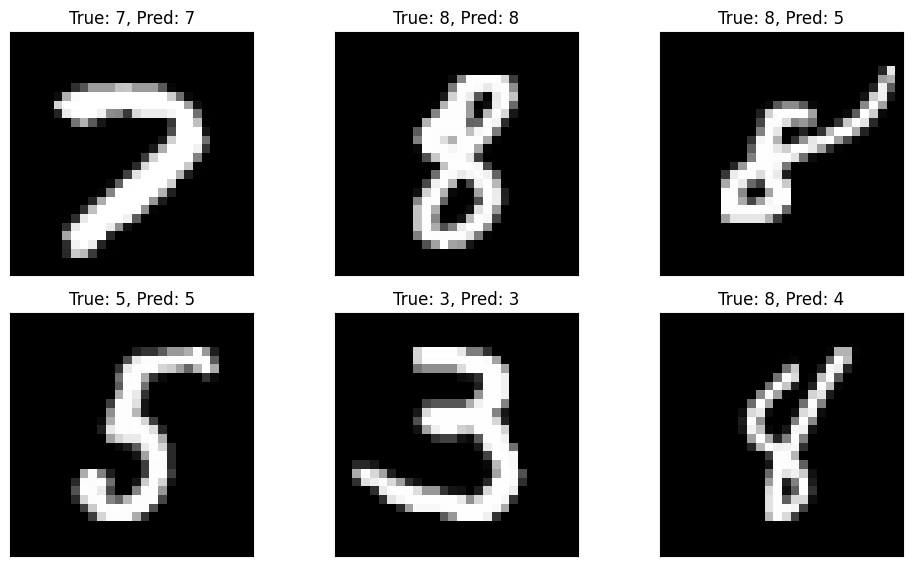

In [12]:
# بعمل ال لوب دي تاني علشان اطلع ال اكيورسي مع الصوره 
model.eval()
with torch.no_grad():
    examples = enumerate(test_dataloader)
    batch_idx, (example_data, example_targets) = next(examples)

    output = model(example_data.to(device))
    _, preds = torch.max(output, 1)

    # نعرض أول 6 صور مع الليبل الحقيقي والتوقع
    plt.figure(figsize=(10, 6))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.tight_layout()
        plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
        plt.title(f"True: {example_targets[i].item()}, Pred: {preds[i].item()}")
        plt.xticks([])
        plt.yticks([])
    plt.show()



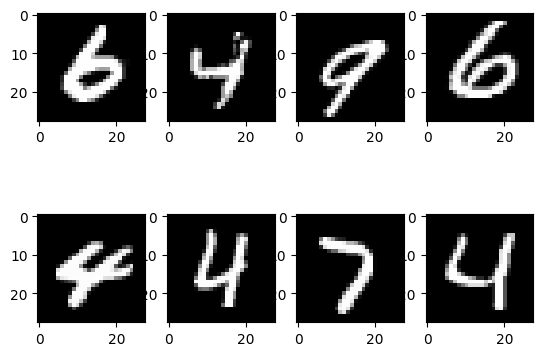

In [14]:
# 2nd
examples = iter(test_dataloader)
example_data , example_targets =next(examples)

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(example_data[i][0], cmap="gray")
plt.show()